In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:


df = pd.read_csv("data/netflix_titles.csv")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [11]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
df['country'].fillna("Unknown", inplace=True)
df['director'].fillna("Not Available", inplace=True)
df['cast'].fillna("Not Available", inplace=True)

C:\Users\Arslan firoz\AppData\Local\Temp\ipykernel_38008\1356899464.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['country'].fillna("Unknown", inplace=True)
C:\Users\Arslan firoz\AppData\Local\Temp\ipykernel_38008\1356899464.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained

0                                           Not Available
1       Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2       Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                           Not Available
4       Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
                              ...                        
8802    Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...
8803                                        Not Available
8804    Jesse Eisenberg, Woody Harrelson, Emma Stone, ...
8805    Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...
8806    Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...
Name: cast, Length: 8807, dtype: str

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [17]:
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')
df['year_added'] = df['date_added'].dt.year

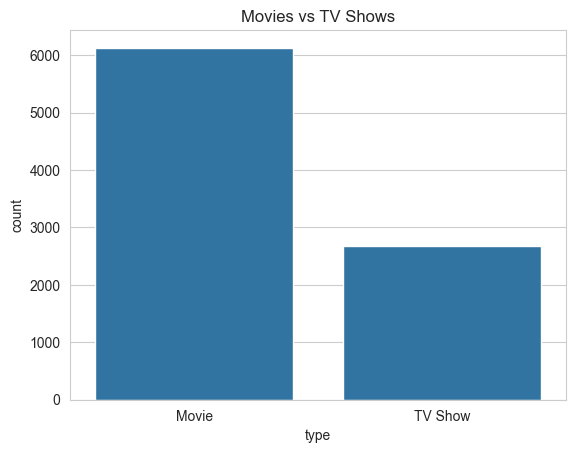

In [18]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

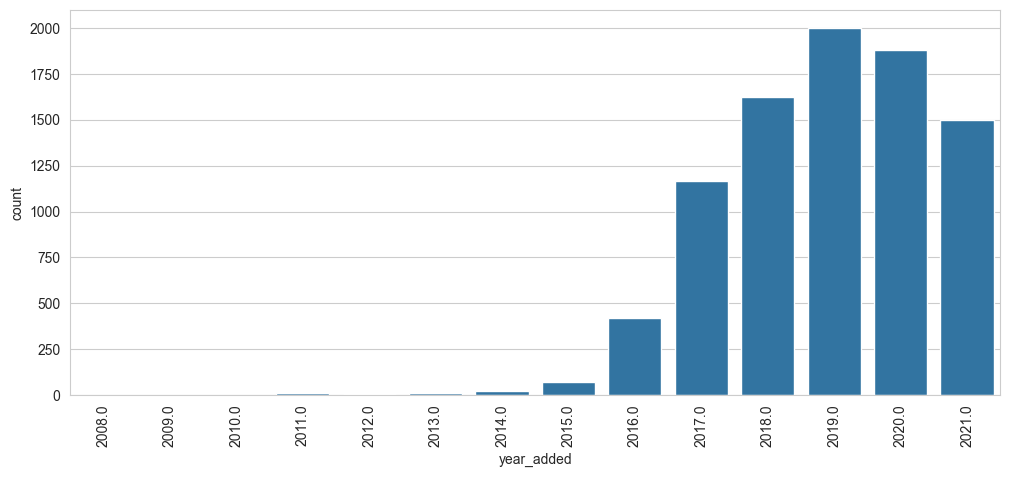

In [20]:
plt.figure(figsize=(12,5))
sns.countplot(x='year_added', data=df)
plt.xticks(rotation=90)
plt.show()

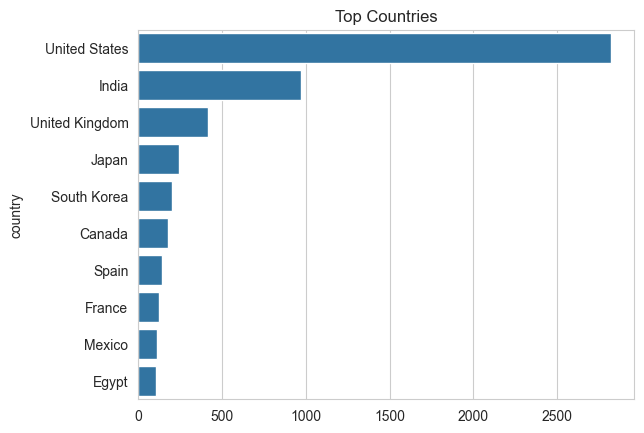

In [21]:
top_country = df['country'].value_counts().head(10)

sns.barplot(x=top_country.values, y=top_country.index)
plt.title("Top Countries")
plt.show()

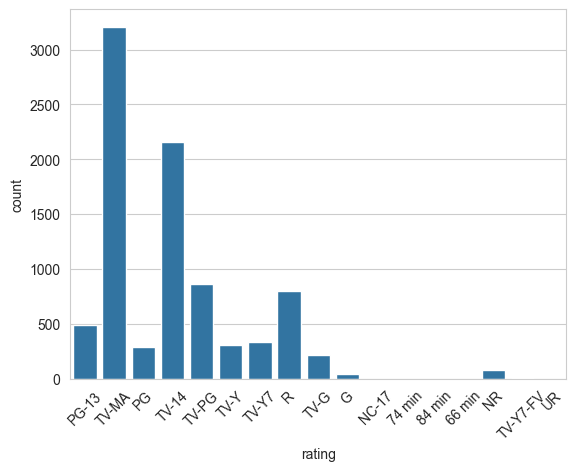

In [23]:
sns.countplot(x='rating', data=df)
plt.xticks(rotation=45)
plt.show()

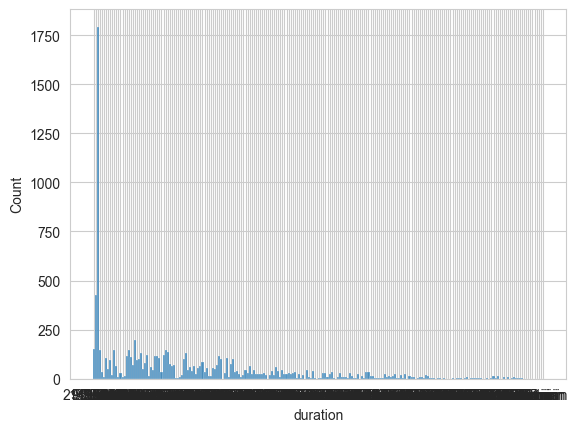

In [25]:
sns.histplot(df['duration'])
plt.show()

In [26]:
df.to_csv("clean_netflix_data.csv", index=False)

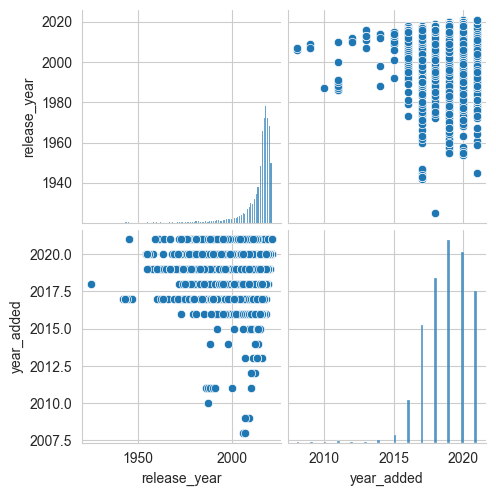

In [28]:
sns.pairplot(df)

<Axes: xlabel='type', ylabel='year_added'>

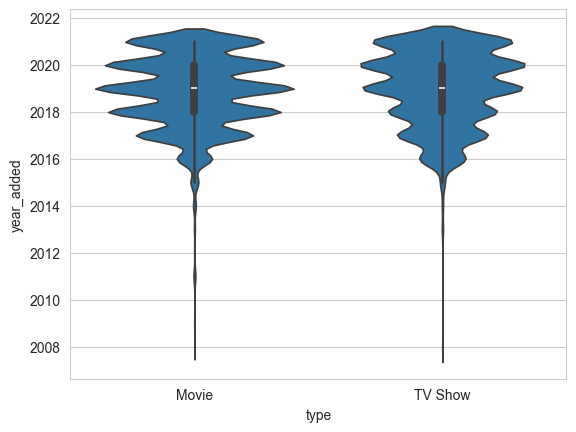

In [29]:
sns.violinplot(x='type', y='year_added', data=df)

<Axes: xlabel='rating', ylabel='year_added'>

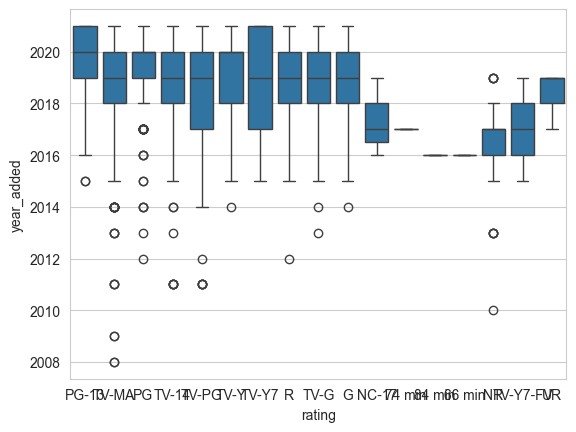

In [30]:
sns.boxplot(x='rating', y='year_added', data=df)

C:\Users\Arslan firoz\AppData\Local\Temp\ipykernel_38008\3047076591.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['year_added'], shade=True)


<Axes: xlabel='year_added', ylabel='Density'>

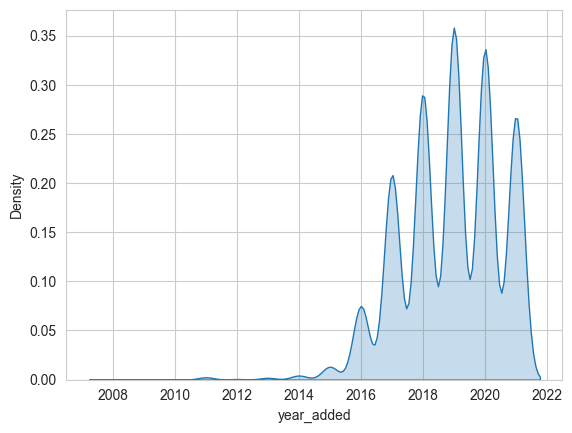

In [31]:
sns.kdeplot(df['year_added'], shade=True)

<Axes: xlabel='type', ylabel='count'>

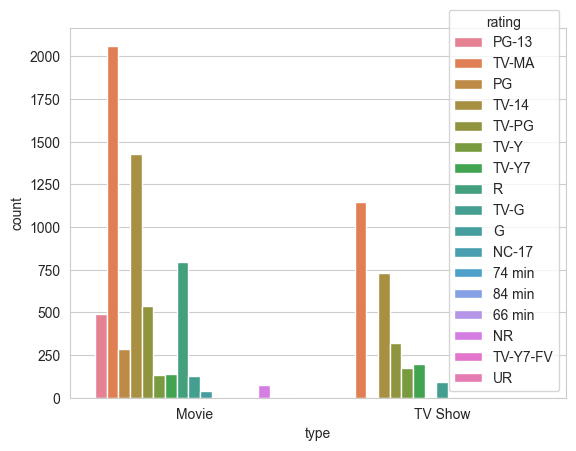

In [32]:
sns.countplot(x='type', hue='rating', data=df)

<Axes: xlabel='type', ylabel='rating'>

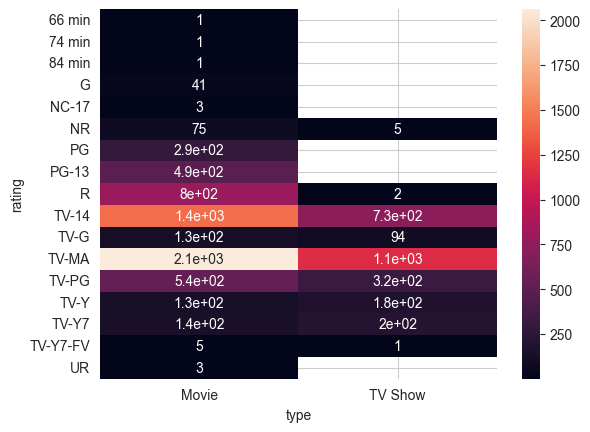

In [33]:
pivot = pd.pivot_table(df, index='rating', columns='type', aggfunc='size')

sns.heatmap(pivot, annot=True)

<Axes: ylabel='country'>

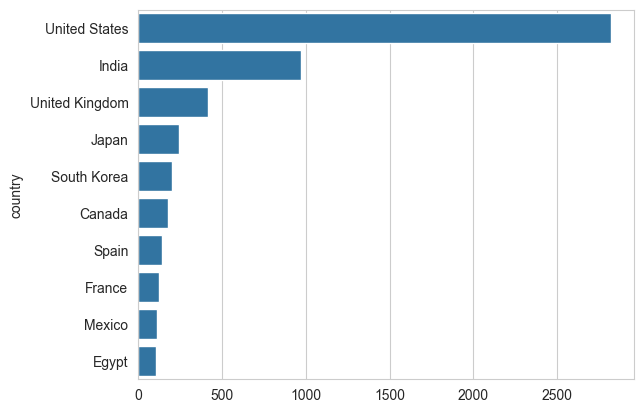

In [34]:
sns.barplot(x=top_country.values, y=top_country.index)

<Axes: xlabel='year_added', ylabel='Count'>

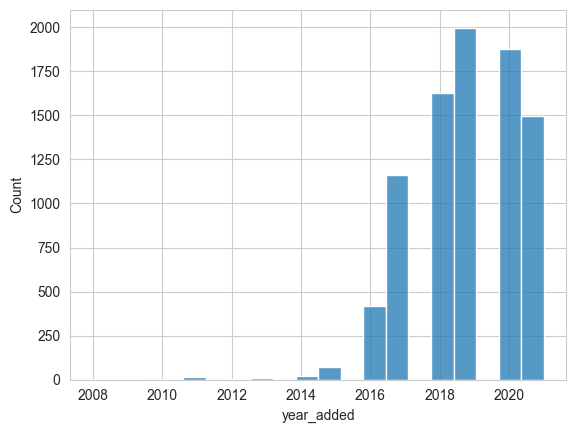

In [35]:
sns.histplot(df['year_added'], bins=20)

<Axes: xlabel='year_added'>

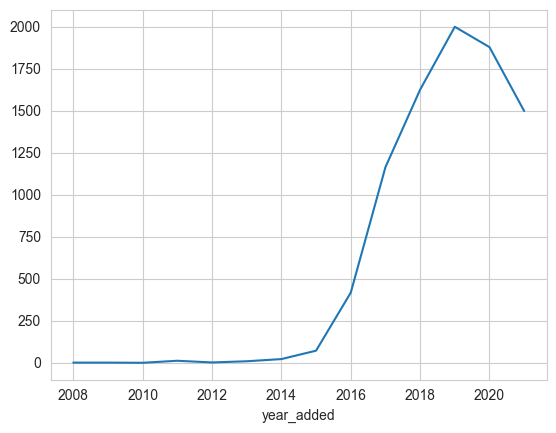

In [36]:
df['year_added'].value_counts().sort_index().plot()

In [37]:
df.to_csv("clean_netflix_data.csv", index=False)